# Mode I benchmark: Leciñana et al. (2023), AS4D/PEKK-FC fatigue specimens

I. Leciñana, J. Renart, A. Turon, J. Zurbitu and B. H. A. H. Tijs, *Characterization and analysis of the mode I interlaminar fatigue behaviour of thermoplastic composites considering R-curve effects*, Engineering Fracture Mechanics 286 (2023) 109273, https://doi.org/10.1016/j.engfracmech.2023.109273.

The paper studies mode I fatigue of AS4D/PEKK-FC DCB specimens (30 plies of 0.138 mm, width 25 mm, length 225 mm, side-clamped loading blocks) with a fatigue cohesive zone model (CF20, ABAQUS UMAT, CPE4 + COH2D4, 0.1 mm elements) and a static cohesive law obtained by superposing five bilinear laws (Table 2). Fatigue is outside the scope of `panels`, and no quasi-static load-displacement curve is given. The paper provides, however, the initial compliance $C = \delta/F$ of five mode I specimens with known initial crack lengths (Table 3 and Fig. 10), measured in the first cycles before any damage, which is a linear elastic mode I result that `panels` can predict.

- Table 1: $E_{11}$ = 138.3 GPa, $E_{22}$ = 10.4 GPa (tensile moduli), $G_{12} = G_{13}$ = 5.19 GPa; $\nu_{12}$ = 0.316 is taken from Tijs et al. (2022);
- Table 3: initial crack lengths 32.05, 33.4, 35.93, 38.05 and 42.97 mm (severities 0.43, 0.38, 0.30, 0.24 and 0.14);
- Fig. 10: the experimental compliance and the numerical one of the three fatigue damage accumulation architectures at the first cycles.

**Digitised data.** The compliances at the first cycles were read from Fig. 10 by eye, with an estimated uncertainty of $\pm 0.0003$ mm/N.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'
# comma-separated keys, runs only these cases (used to run cases in parallel)
ONLY = os.environ.get('DCB_CASES')
ONLY = ONLY.split(',') if ONLY else None


## Specimens and compliance data

In [2]:
spec = dict(E1=138300., E2=10400., nu12=0.316, G12=5190., h=15*0.138, b=25., G1c=1.12)

exp_tests = {
    'initial_compliance': dict(source='Table 3 and Fig. 10 (experimental onset data, first cycles)',
        a0=np.array([32.05, 33.4, 35.93, 38.05, 42.97]),
        C=np.array([0.0115, 0.0129, 0.0164, 0.0190, 0.0265])),
}
fe_cases = {
    'CF20_FCZM': dict(source='Fig. 10e, numerical onset, superposition architecture 3, first cycles',
        model='ABAQUS/Standard, CPE4 + COH2D4 with the CF20 fatigue UMAT, 0.1 mm elements, 5 superposed bilinear laws',
        a0=np.array([32.05, 33.4, 35.93, 38.05, 42.97]),
        C=np.array([0.0110, 0.0127, 0.0161, 0.0190, 0.0263])),
}


## panels model

Linear elastic analysis of the DCB with `dcb_utils.elastic_compliance`: same model as in the other notebooks, with an opening of 0.05 mm, well below the damage onset. The specimen length is taken as $a_0 + 100$ mm; the compliance does not depend on it for this length. The reference is the corrected beam theory, $C = 2 (a + \chi h)^3/(3 E I)$ with $E I = D_{11} b$.

| $a_0$ (mm) | test (mm/N) | FE (mm/N) | panels (mm/N) | CBT (mm/N) | panels vs test | panels vs FE | panels vs CBT |
|---|---|---|---|---|---|---|---|
| 32.05 | 0.0115 | 0.0110 | 0.0096 | 0.0119 | -16.9% | -13.2% | -20.0% |
| 33.40 | 0.0129 | 0.0127 | 0.0108 | 0.0133 | -16.6% | -15.3% | -19.3% |
| 35.93 | 0.0164 | 0.0161 | 0.0133 | 0.0162 | -18.9% | -17.4% | -18.1% |
| 38.05 | 0.0190 | 0.0190 | 0.0157 | 0.0190 | -17.3% | -17.3% | -17.2% |
| 42.97 | 0.0265 | 0.0263 | 0.0224 | 0.0265 | -15.5% | -14.8% | -15.5% |

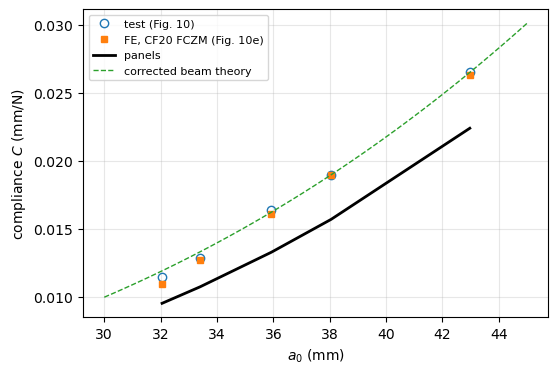

In [3]:
a0 = exp_tests['initial_compliance']['a0']
C_panels = np.array([du.elastic_compliance(dict(spec, L=a + 100., a0=a, k_o=1.e5, tau_o=87.,
                                                L_tsl=20., m_tsl=15, nx=60), a)
                     for a in a0])
C_cbt = du.compliance_cbt(dict(spec, L=100., a0=40.), a0)
C_exp = exp_tests['initial_compliance']['C']
C_fe = fe_cases['CF20_FCZM']['C']
lines = ['| $a_0$ (mm) | test (mm/N) | FE (mm/N) | panels (mm/N) | CBT (mm/N) | panels vs test | panels vs FE | panels vs CBT |', '|---|---|---|---|---|---|---|---|']
for a, ce, cf, cp, cb in zip(a0, C_exp, C_fe, C_panels, C_cbt):
    lines.append(f'| {a:.2f} | {ce:.4f} | {cf:.4f} | {cp:.4f} | {cb:.4f} | {100*(cp/ce - 1):+.1f}% | {100*(cp/cf - 1):+.1f}% | {100*(cp/cb - 1):+.1f}% |')
display(Markdown('\n'.join(lines)))
fig, ax = plt.subplots(figsize=(6, 4))
aa = np.linspace(30, 45, 50)
ax.plot(a0, C_exp, 'o', mfc='none', label='test (Fig. 10)')
ax.plot(a0, C_fe, 's', ms=4, label='FE, CF20 FCZM (Fig. 10e)')
ax.plot(a0, C_panels, 'k-', lw=2, label='panels')
ax.plot(aa, du.compliance_cbt(dict(spec, L=100., a0=40.), aa), '--', lw=1, label='corrected beam theory')
ax.set_xlabel('$a_0$ (mm)')
ax.set_ylabel('compliance $C$ (mm/N)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()


## Discussion

- **Compliance.** panels predicts compliances 15.5-18.9% below the measured ones and 13-17% below the FE of the paper, while the corrected beam theory matches the tests within 4%. The difference is the flexibility that the CLPT arms of `panels` do not have: transverse shear deformation, which is large for AS4D/PEKK-FC ($E_{11}/G_{13}$ = 27), and the rotation at the crack front, which in `panels` comes only from the elastic foundation of the cohesive interface. The corrected beam theory accounts for both through $\chi h$ = 3.7 mm, i.e. an effective crack length 9-12% longer, which corresponds to a compliance 28-39% higher than simple beam theory; `panels` recovers part of it through the foundation.
- **Consequence for the fracture analyses.** In the load-opening curves of the other notebooks, the same effect appears as an initial stiffness 9-17% higher than the corrected beam theory, while the peak loads, controlled by the energy release rate, stay within a few percent of it.
- **Fatigue.** The fatigue onset and propagation of the paper are outside the scope of `panels`.